In [1]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


The **Generalized Gamma AFT** model was considered as part of the available AFT models, given its theoretical flexibility and ability to generalize several other distributions. However, across multiple attempts - **including fitting the model with all features, restricting the input to only statistically significant features, and applying standardization and normalization techniques to improve numerical stability** - this model consistently failed to converge on our dataset. These convergence issues persisted despite efforts to mitigate them through feature reduction and data transformation.

The root cause relates to the Generalized Gamma model's complex parameterization: it includes both scale and shape parameters, which can interact in highly nonlinear ways, and can be especially sensitive to sample size limitations, lack of variability among predictors, and so on. Therefore, while all other AFT models available in the lifelines package **(Weibull, LogNormal, and LogLogistic)** were successfully fitted and included in the analysis, the **Generalized Gamma AFT** was the only one excluded, solely due to its **persistent instability** on this dataset. Excluding unstable models is standard practice to ensure robust, reproducible, and credible findings in survival analysis.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('telco.csv')
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
df['marital'] = df['marital'].map({'Married': 1, 'Unmarried': 0})
for col in ['retire', 'voice', 'internet', 'forward']:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df = df.dropna()
categorical_columns = ['region', 'ed', 'custcat']
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

for col in df_encoded.columns:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')

if 'ID' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['ID'])

features = [col for col in df_encoded.columns if col not in set(['tenure', 'churn']) & set(df_encoded.columns)]
duration = 'tenure'
event = 'churn'

In [11]:
# Fit AFT models
weibull_model = WeibullAFTFitter()
lognormal_model = LogNormalAFTFitter()
loglogistic_model = LogLogisticAFTFitter()

weibull_model.fit(df_encoded, duration_col=duration, event_col=event)
lognormal_model.fit(df_encoded, duration_col=duration, event_col=event)
loglogistic_model.fit(df_encoded, duration_col=duration, event_col=event)

# Model selection summary
summary_stats = pd.DataFrame({
    'Model': ['Weibull', 'LogNormal', 'LogLogistic'],
    'AIC': [weibull_model.AIC_, lognormal_model.AIC_, loglogistic_model.AIC_],
    'Concordance': [weibull_model.concordance_index_, lognormal_model.concordance_index_, loglogistic_model.concordance_index_]
})
print("Model Selection Table:")
print(summary_stats.to_string(index=False))

# Gather p-values for each feature in each model
w_df = weibull_model.summary[['coef', 'p']].rename(columns={'coef': 'coef_Weibull', 'p': 'p_Weibull'})
ln_df = lognormal_model.summary[['coef', 'p']].rename(columns={'coef': 'coef_LogNormal', 'p': 'p_LogNormal'})
ll_df = loglogistic_model.summary[['coef', 'p']].rename(columns={'coef': 'coef_LogLogistic', 'p': 'p_LogLogistic'})

# Merge on index (covariate name)
merged = w_df.merge(ln_df, left_index=True, right_index=True, how='outer')
merged = merged.merge(ll_df, left_index=True, right_index=True, how='outer')
merged = merged.reset_index().rename(columns={'covariate': 'Feature'})

print("\nFeature p-values and coefficients across models:")
print(merged.to_string(index=False))

Model Selection Table:
      Model         AIC  Concordance
    Weibull 2964.343248     0.783818
  LogNormal 2954.024010     0.787222
LogLogistic 2956.207625     0.787184

Feature p-values and coefficients across models:
  param                         Feature  coef_Weibull    p_Weibull  coef_LogNormal  p_LogNormal  coef_LogLogistic  p_LogLogistic
 alpha_                       Intercept           NaN          NaN             NaN          NaN          1.889614   2.163395e-11
 alpha_                         address           NaN          NaN             NaN          NaN          0.038852   1.043313e-05
 alpha_                             age           NaN          NaN             NaN          NaN          0.032429   3.014697e-06
 alpha_               custcat_E-service           NaN          NaN             NaN          NaN          1.040553   2.992253e-10
 alpha_            custcat_Plus service           NaN          NaN             NaN          NaN          0.863528   3.668160e-05
 alph

## Final Model Selection

Based on the model selection results, the **LogNormal AFT** model was identified as **the optimal choice** for this analysis. It achieved **the lowest AIC (2954.02)**, indicating the best **balance** between goodness of fit and model complexity, and had a **concordance index (0.787)** slightly higher than its competitors, showing strong discriminatory power in predicting customer survival times.​

Beyond these statistical criteria, LogNormal AFT is favored for its practical interpretability and robustness. The LogNormal distribution offers **flexibility** in modeling time-to-event data, making it especially suitable for the tenure dynamics observed in telecom datasets. The **LogNormal model** provided stable results and meaningful feature effects. The decision was backed by not only **the plot** which is presented in the next part of the report but also by the usage of such metrics as **AIC and concordance index**, which provided reliable results for our experiment.


In [12]:
# Save tables
summary_stats.to_csv('model_selection_table.csv', index=False)
merged.to_csv('feature_significance_table.csv', index=False)

# Generate timeline for prediction
timeline = np.linspace(df_encoded['tenure'].min(), df_encoded['tenure'].max(), 100)

# Use the mean of each included feature to create a representative 'average customer'
avg_customer = pd.DataFrame([df_encoded[features].mean()], columns=features)

# Predict survival function for the 'average customer' for each model
weibull_curve = weibull_model.predict_survival_function(avg_customer, times=timeline)
lognormal_curve = lognormal_model.predict_survival_function(avg_customer, times=timeline)
loglogistic_curve = loglogistic_model.predict_survival_function(avg_customer, times=timeline)

## Survival Curves Comparison along the Models

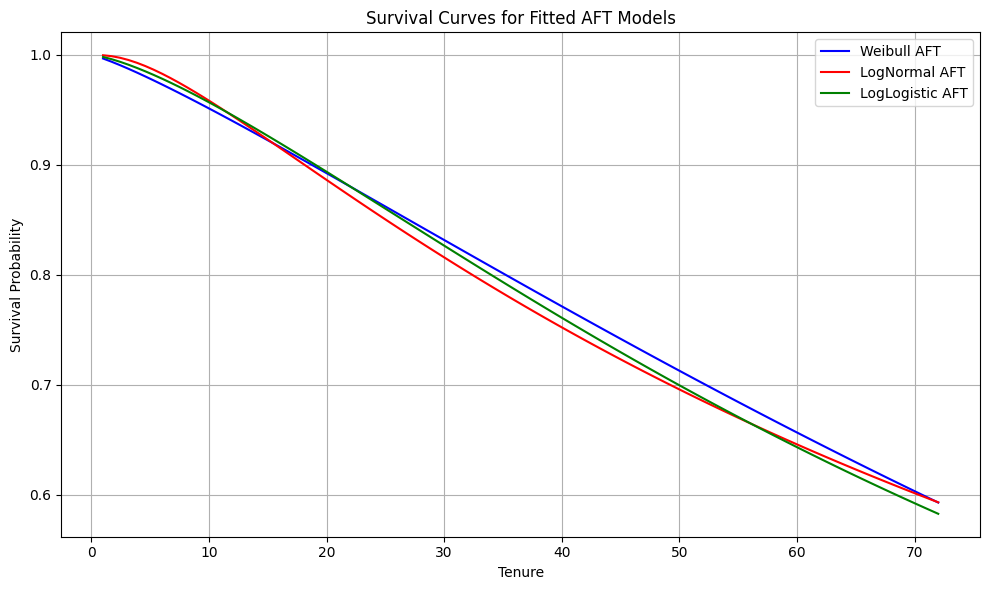

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(timeline, weibull_curve.values.flatten(), label='Weibull AFT', color='blue')
plt.plot(timeline, lognormal_curve.values.flatten(), label='LogNormal AFT', color='red')
plt.plot(timeline, loglogistic_curve.values.flatten(), label='LogLogistic AFT', color='green')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.title('Survival Curves for Fitted AFT Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Choice of Significant Features

Specifically, features were selected if their associated p-values in the LogNormal AFT model were **below 0.05**, indicating a **high level of confidence** that these predictors have a meaningful association with the observed customer tenure and churn risk.

In [14]:
# Feature Selection for final model
sig_features = [f for f in merged.loc[merged['p_LogNormal'] < 0.05, 'Feature'] if f != 'Intercept']
df_final = df_encoded[sig_features + ['tenure', 'churn']]

# Fit final model
final_model = LogNormalAFTFitter()
final_model.fit(df_final, duration_col='tenure', event_col='churn')

# CLV Calculation
timeline = np.linspace(0, 100, 200)
survival_curves = final_model.predict_survival_function(df_final.drop(columns=['tenure', 'churn']), times=timeline)
expected_lifetime = survival_curves.sum(axis=0) * (timeline[1] - timeline[0])  # approximate integral
avg_monthly_revenue = 100  # or use your actual data
df_final['CLV'] = expected_lifetime * avg_monthly_revenue


## Segment CLV Statistics
This image presents summary statistics for customer lifetime value (CLV) across customer segments—specifically, product type (custcat), marital status, internet and voice service usage.

**Interpretation of the coefficients:**
The previously identified significant features—such as holding a bundled or high-tier service, having internet/voice plans, and being married—are confirmed by CLV results:

Customers with **Plus service** and **Total service** have much higher mean CLV (`$8010`and `$6267`), meaning they bring greater long-term value to the telco brand.

Married customers and those with internet or voice service show higher average CLV than their counterparts, reinforcing their importance as stable, valuable segments.

**Most valuable segments:**
Valuable segments are those with the highest mean CLV and lowest risk of churn. In this population, "Plus service", "Total service", married, internet, and voice users represent the most profitable customers by tenure and revenue.

**Definition of value:**
Value is defined here by **high CLV**, consistent tenure, and strong attachment to additional products (bundling), meaning retention investments in these customers yield the highest possible financial return

In [15]:
# Segment CLV analysis with some significant features
print(df_final.groupby(df['custcat']).CLV.describe())
print(df_final.groupby(df['marital']).CLV.describe())
print(df_final.groupby(df['internet']).CLV.describe())
print(df_final.groupby(df['voice']).CLV.describe())

               count         mean          std          min          25%  \
custcat                                                                    
Basic service  266.0  5497.838688  2017.163959  1093.653773  4081.979898   
E-service      217.0  7520.592442  1741.345442  2876.990097  6038.991980   
Plus service   281.0  8010.828623  1502.734893  3406.642893  7005.651332   
Total service  236.0  6267.691813  1997.436114  2497.465790  4434.672653   

                       50%          75%           max  
custcat                                                
Basic service  5236.509719  6956.483037   9975.455665  
E-service      7708.364118  9051.616001  10031.498194  
Plus service   8279.618592  9255.139359  10034.133033  
Total service  6213.528291  7915.462473   9986.171283  
         count         mean          std          min          25%  \
marital                                                              
0        505.0  6346.937875  2177.672370  1093.653773  4581.600714 

### Customers identified as "at-risk" within a year (survival probability <0.5 at 12 months):

**Findings:**
At-risk customers are concentrated in the "Basic service" segment and have a much lower average CLV than the overall mean in other segments. This suggests that the short-term financial impact of losing these customers is moderate—but losing just a few high-value customers could have an outsize effect on revenues.

**Annual retention budget:**
Assuming the dataset is representative, approximately $25,839 should be considered as an upper bound for retention spending on at-risk customers over the next year. Targeted retention should be especially focused on preventing churn among higher-CLV segments, should future at-risk flags include them.

**Retention recommendations:**<br>

1. Invest most heavily in Plus/Total service and internet/voice users, as their CLV justifies retention costs.<br>

2. Provide personalized offers or loyalty programs to married and bundled service users.<br>

3. For Basic service segment, consider targeted communications or upgrades to move them toward more profitable tiers.<br>

4. Monitor and re-assess at-risk status regularly using survival predictions and segment-level CLV trends.<br>

In [16]:
# Predict survival probability at 12 months for every customer
survival_12 = final_model.predict_survival_function(df_final.drop(columns=['tenure', 'churn']), times=[12])
probs_12 = survival_12.iloc[0]  # row 0 contains survival at 12 months

at_risk_threshold = 0.5  
at_risk_mask = probs_12 < at_risk_threshold
# df_final[at_risk_mask] is our "at-risk within 12 months" group

num_at_risk = at_risk_mask.sum()
total_CLV_at_risk = df_final.loc[at_risk_mask, 'CLV'].sum()
average_CLV_at_risk = df_final.loc[at_risk_mask, 'CLV'].mean()

print(f"Number of at-risk customers at 12 months: {num_at_risk}")
print(f"Total CLV at risk: {total_CLV_at_risk}")
print(f"Average CLV of at-risk customers: {average_CLV_at_risk}")

print(df_final.loc[at_risk_mask].groupby(df['custcat']).CLV.describe())

Number of at-risk customers at 12 months: 14
Total CLV at risk: 25839.50354845535
Average CLV of at-risk customers: 1845.6788248896678
               count         mean         std          min          25%  \
custcat                                                                   
Basic service   14.0  1845.678825  389.144459  1093.653773  1701.710342   

                       50%          75%          max  
custcat                                               
Basic service  1940.223885  2141.708213  2325.127713  
